# Notebook 1: Day-Ahead Solar Irradiance Forecasting

**AI Bootcamp — Applied AI for Power and Energy Systems**  
CSU Energy Institute | Fort Collins, CO

---

## Learning objectives

By the end of this notebook you will be able to:

1. Load and explore a real hourly solar irradiance dataset
2. Construct a **time-ordered train / validation / test split** and explain why random splitting is wrong for time series
3. Build and evaluate three forecasting models of increasing complexity:
   - Persistence baseline
   - Random forest
   - Small PyTorch MLP
4. Interpret evaluation metrics (MAE, RMSE, skill score) in the context of power systems
5. Visualize actual vs. predicted solar output and diagnose model errors

---

## The forecasting problem

We want to predict **tomorrow's hourly solar irradiance** at Fort Collins, CO using only information available today.

$$\hat{P}_{t+24} = f_\theta(\mathbf{x}_t)$$

Each row in our dataset is one hour. The model predicts the irradiance value 24 hours into the future from the feature vector $\mathbf{x}_t$, which contains calendar features, weather forecast proxies, clear-sky physics, and lag observations.

> **Note on weather inputs:** In a real operational pipeline, `temp_forecast` and `cloud_forecast` would come from a Numerical Weather Prediction (NWP) model such as NOAA GFS or Open-Meteo's forecast API. Here we use tomorrow's *actual observed* values as a **perfect forecast proxy** — a standard academic benchmarking practice. This isolates the solar forecasting problem from the weather forecasting problem and sets an upper bound on achievable performance.


## 0. Setup and imports

In [120]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 469
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Device ───────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Plot style ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi"     : 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size"      : 11,
})
sns.set_palette("colorblind")

print("Python :", sys.version.split()[0])
print("NumPy  :", np.__version__)
print("pandas :", pd.__version__)
print("PyTorch:", torch.__version__)
print("Device :", device)
if torch.cuda.is_available():
    print("GPU    :", torch.cuda.get_device_name(0))


# ── PV System Parameters ─────────────────
# Adapted for Powerhouse Energy Campus, CSU, Fort Collins
# PV Modeling guide by Sandia National Laboratory
LAT_RAD        = np.radians(40.5942)
PANEL_TILT     = np.radians(30)        # β
PANEL_AZIMUTH  = np.radians(0)         # γp — south-facing
SURFACE_ALBEDO = 0.2                   # ρ
T_REF          = 25.0                  # °C
DELTA_T        = 25.0                  # °C
P_RATED        = 100000.0               # W — 100 kW system
ETA_DERATE     = 0.90
ETA_INV        = 0.945
GAMMA          = -0.004               # /°C


def ghi_to_ac_power(ghi, t_amb, clearsky_ghi_ref):
    """
     Convert GHI to AC power following PV Modeling guide by Sandia National Laboratory: GHI → POA → DC → AC.
    Solar geometry is delegated to pvlib via clearsky_ghi_ref.
    """
    ghi              = np.array(ghi,              dtype=float)
    t_amb            = np.array(t_amb,            dtype=float)
    clearsky_ghi_ref = np.array(clearsky_ghi_ref, dtype=float)

    # POA irradiance — south-facing 30° tilt
    f_tilt = np.cos(PANEL_TILT) + np.sin(PANEL_TILT) * SURFACE_ALBEDO
    I_POA  = np.clip(ghi * f_tilt, 0, None)

    # Cell temperature
    T_cell = t_amb + (I_POA / 800.0) * DELTA_T

    # DC power with temperature correction
    P_DC = (P_RATED * ETA_DERATE *
            (I_POA / 1000.0) *
            (1 + GAMMA * (T_REF - T_cell)))
    P_DC = np.clip(P_DC, 0, P_RATED)

    # AC power via inverter efficiency
    P_AC = np.clip(P_DC * ETA_INV, 0, P_RATED * ETA_INV)

    # Nighttime mask — pvlib clearsky already accounts for solar geometry
    return np.where(clearsky_ghi_ref <= 0, 0.0, P_AC)


Python : 3.10.20
NumPy  : 2.2.6
pandas : 2.3.3
PyTorch: 2.11.0+cpu
Device : cpu


## 1. Load and explore the dataset

The dataset covers **June 2025 – May 2026** at Powerhouse Energy Campus, CSU, Fort Collins, CO  (40.5944 N, 105.07594 W),
sourced from the Open-Meteo ERA5 reanalysis archive at hourly resolution.


In [121]:
# ── Load ───────────────────────────────────────────────────

DATA_PATH = r"C:\Users\C838122727\Documents\CSU\research\Projects\AI_Bootcamp_Week3\data\workshop\solar_forecasting.csv"   # local

df = pd.read_csv(DATA_PATH, index_col="timestamp", parse_dates=True)
df.index = pd.to_datetime(df.index, utc=True).tz_convert("America/Denver")

print(f"Shape        : {df.shape}")
print(f"Date range   : {df.index[0]}  →  {df.index[-1]}")
print(f"Missing values:\n{df.isnull().sum()}")
df.head(3)


Shape        : (8712, 15)
Date range   : 2025-06-02 18:00:00-06:00  →  2026-05-31 17:00:00-06:00
Missing values:
hour                 0
day_of_year          0
sin_hour             0
cos_hour             0
sin_doy              0
cos_doy              0
temp_forecast        0
cloud_forecast       0
humidity_forecast    0
precip_forecast      0
clearsky_ghi         0
solar_rad_t24        0
solar_rad_t48        0
solar_radiation      0
target_t24           0
dtype: int64


,hour,day_of_year,sin_hour,cos_hour,sin_doy,cos_doy,temp_forecast,cloud_forecast,humidity_forecast,precip_forecast,clearsky_ghi,solar_rad_t24,solar_rad_t48,solar_radiation,target_t24
timestamp,,,,,,,,,,,,,,,
2025-06-02 18:00:00-06:00,18,153,-1.000000,-1.836970e-16,0.486273,-0.873807,14.1,70.0,60.0,0.0,383.856022,417.0,402.0,215.0,217.0
2025-06-02 19:00:00-06:00,19,153,-0.965926,2.588190e-01,0.486273,-0.873807,12.9,96.0,68.0,0.0,173.225039,200.0,231.0,138.0,53.0
2025-06-02 20:00:00-06:00,20,153,-0.866025,5.000000e-01,0.486273,-0.873807,12.2,77.0,72.0,0.0,12.697173,88.0,77.0,33.0,30.0


In [122]:
# ── Feature overview ─────────────────────────────────────────────────────────
print("Columns and dtypes:")
print(df.dtypes)
print()
print("Basic statistics for key columns:")
cols_show = ["solar_radiation", "target_t24", "clearsky_ghi",
             "cloud_forecast", "temp_forecast"]
df[cols_show].describe().round(1)


Columns and dtypes:
hour                   int64
day_of_year            int64
sin_hour             float64
cos_hour             float64
sin_doy              float64
cos_doy              float64
temp_forecast        float64
cloud_forecast       float64
humidity_forecast    float64
precip_forecast      float64
clearsky_ghi         float64
solar_rad_t24        float64
solar_rad_t48        float64
solar_radiation      float64
target_t24           float64
dtype: object

Basic statistics for key columns:


,solar_radiation,target_t24,clearsky_ghi,cloud_forecast,temp_forecast
count,8712.0,8712.0,8712.0,8712.0,8712.0
mean,197.5,198.0,242.0,49.5,11.6
std,268.1,268.5,324.4,40.4,10.1
min,0.0,0.0,0.0,0.0,-27.9
25%,0.0,0.0,0.0,4.0,4.1
50%,10.0,10.0,0.3,49.0,11.7
75%,381.0,382.0,473.3,95.0,18.7
max,1018.0,1018.0,1029.6,100.0,36.4


### 1.1 Exploratory data analysis

Before modelling, always look at the data. Three questions to answer:
- Does the diurnal cycle look physically correct?
- Is there visible seasonality?


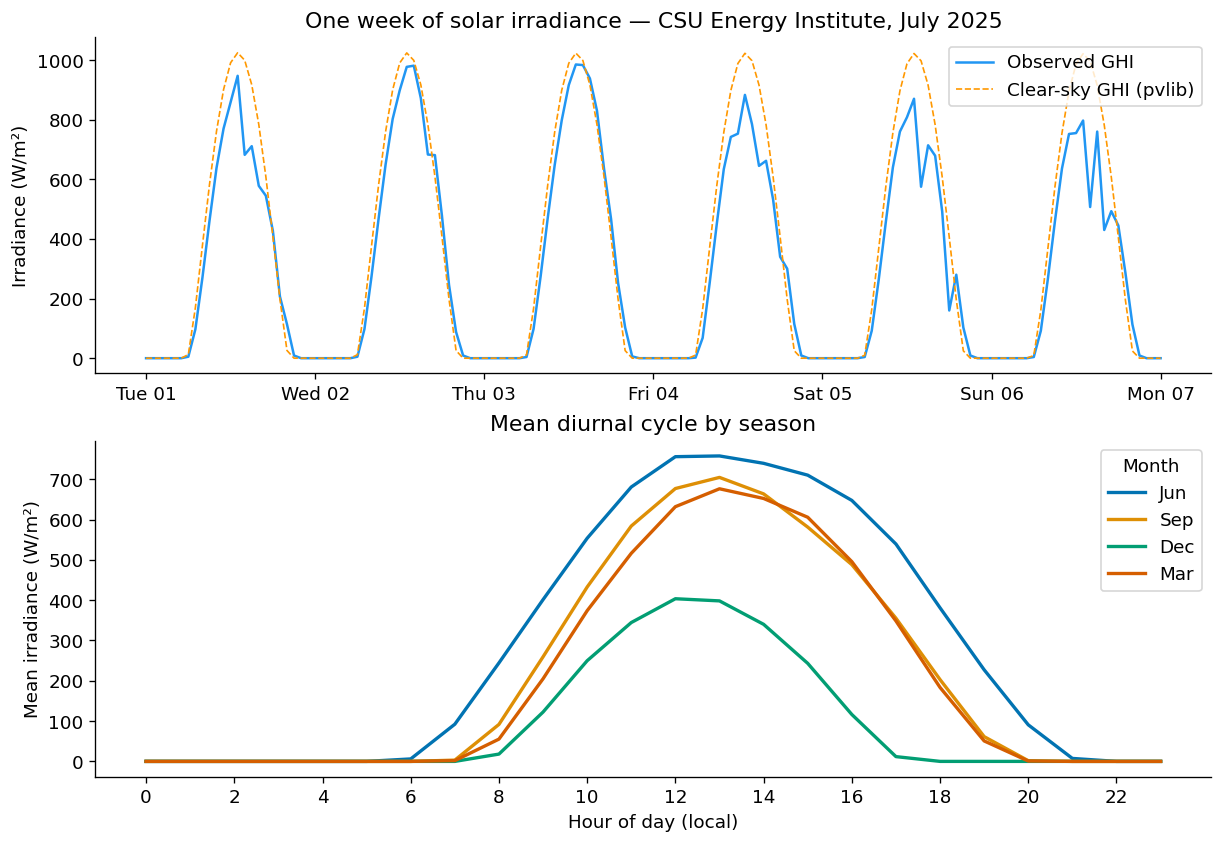

In [123]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# ── Panel 1: one week of raw irradiance ──────────────────────────────────────
week_mask = (df.index >= pd.Timestamp("2025-07-01", tz="America/Denver")) & \
            (df.index <= pd.Timestamp("2025-07-07", tz="America/Denver"))
week = df[week_mask]
ax = axes[0]
ax.plot(week.index, week["solar_radiation"],  color="#2196F3", lw=1.5,
        label="Observed GHI")
ax.plot(week.index, week["clearsky_ghi"],     color="#FF9800", lw=1,
        ls="--", label="Clear-sky GHI (pvlib)")
ax.set_ylabel("Irradiance (W/m²)")
ax.set_title("One week of solar irradiance — CSU Energy Institute, July 2025")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%a %d"))

# ── Panel 2: monthly mean diurnal cycle ──────────────────────────────────────
ax = axes[1]
months = {"Jun": 6, "Sep": 9, "Dec": 12, "Mar": 3}
for label, m in months.items():
    monthly = df[df.index.month == m].groupby("hour")["solar_radiation"].mean()
    ax.plot(monthly.index, monthly.values, lw=2, label=label)
ax.set_xlabel("Hour of day (local)")
ax.set_ylabel("Mean irradiance (W/m²)")
ax.set_title("Mean diurnal cycle by season")
ax.legend(title="Month")
ax.set_xticks(range(0, 24, 2))

fig_path = Path(r"C:\Users\C838122727\Documents\CSU\research\Projects\AI_Bootcamp_Week3\outputs\figures")
fig_path.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path / "eda_solar.png", bbox_inches="tight", dpi=150)
plt.show()


## 2. Time-ordered train / validation / test split

> **Why not random split?**  
> Solar irradiance has strong temporal autocorrelation. A random split would  
> let the model "see" data from the future during training — information leakage  
> that would give misleadingly optimistic test metrics. We always split by time.

```
│◄────── Train 70% ──────►│◄── Val 15% ──►│◄── Test 15% ──►│
Jun 2025                                                    May 2026
```


In [124]:
# ── Feature columns and target ───────────────────────────────────────────────
FEATURE_COLS = [
    # Calendar
    "sin_hour", "cos_hour", "sin_doy", "cos_doy",
    # Weather forecast proxy
    "temp_forecast", "cloud_forecast", "humidity_forecast", "precip_forecast",
    # Physics
    "clearsky_ghi",
    # Lag observations
    "solar_rad_t24", "solar_rad_t48",
]
TARGET_COL = "target_t24"

X = df[FEATURE_COLS].values.astype(np.float32)
y = df[TARGET_COL].values.astype(np.float32)

n       = len(df)
n_train = int(n * 0.70)
n_val   = int(n * 0.15)
n_test  = n - n_train - n_val

X_train, y_train = X[:n_train],            y[:n_train]
X_val,   y_val   = X[n_train:n_train+n_val], y[n_train:n_train+n_val]
X_test,  y_test  = X[n_train+n_val:],      y[n_train+n_val:]

idx_train = df.index[:n_train]
idx_val   = df.index[n_train:n_train+n_val]
idx_test  = df.index[n_train+n_val:]

print(f"Train : {len(X_train):,} rows  ({idx_train[0].date()} → {idx_train[-1].date()})")
print(f"Val   : {len(X_val):,} rows  ({idx_val[0].date()} → {idx_val[-1].date()})")
print(f"Test  : {len(X_test):,} rows  ({idx_test[0].date()} → {idx_test[-1].date()})")


Train : 6,098 rows  (2025-06-02 → 2026-02-11)
Val   : 1,306 rows  (2026-02-11 → 2026-04-07)
Test  : 1,308 rows  (2026-04-07 → 2026-05-31)


## 3. Persistence baseline

The simplest possible forecast: **tomorrow will look like today**.

$$\hat{P}_{t+24} = P_t$$

This uses `solar_rad_t24` — the observed irradiance from the same hour yesterday —  
as the prediction. Any model that cannot beat this baseline is not useful.

The persistence baseline is the standard benchmark in solar forecasting literature.


In [125]:
def evaluate(y_true, y_pred, name="Model"):
    """Compute MAE, RMSE, and skill score vs. persistence."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    # Normalised RMSE (as % of mean observed)
    nrmse = rmse / (y_true.mean() + 1e-8) * 100
    return {"Model": name, "MAE": mae, "RMSE": rmse, "nRMSE (%)": nrmse}

# Persistence: y_hat = solar_rad_t24 on test set
y_pers = X_test[:, FEATURE_COLS.index("solar_rad_t24")]

results = []
results.append(evaluate(y_test, y_pers, name="Persistence"))

print(f"Persistence baseline on test set:")
print(f"  MAE   = {results[0]['MAE']:.1f} W/m²")
print(f"  RMSE  = {results[0]['RMSE']:.1f} W/m²")
print(f"  nRMSE = {results[0]['nRMSE (%)']:.1f} %")


Persistence baseline on test set:
  MAE   = 79.7 W/m²
  RMSE  = 157.1 W/m²
  nRMSE = 59.7 %


## 4. Feature scaling

Tree-based models (random forest) do not require scaling.  
Neural networks converge much faster when inputs are standardised.

We fit the scaler **only on the training set** and apply it to val and test.  
Fitting on the full dataset would leak future statistics into training — a subtle  
but common mistake.


In [126]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_s = scaler_X.fit_transform(X_train)
X_val_s   = scaler_X.transform(X_val)
X_test_s  = scaler_X.transform(X_test)

y_train_s = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
y_val_s   = scaler_y.transform(y_val.reshape(-1, 1)).ravel()

print("Feature means (train, first 4):", scaler_X.mean_[:4].round(3))
print("Feature stds  (train, first 4):", scaler_X.scale_[:4].round(3))
print("Target mean / std (train):",
      scaler_y.mean_[0].round(1), "/", scaler_y.scale_[0].round(1))


Feature means (train, first 4): [-0.     0.    -0.371  0.042]
Feature stds  (train, first 4): [0.707 0.707 0.507 0.777]
Target mean / std (train): 185.1 / 256.7


## 5. Random forest

A random forest is an ensemble of decision trees trained on random feature subsets.  
It handles nonlinear interactions and is robust to scale — no normalisation needed.

**Key hyperparameters:**
- `n_estimators`: number of trees (more = better, diminishing returns after ~200)
- `max_depth`: limits tree depth to prevent overfitting
- `min_samples_leaf`: minimum samples at each leaf


In [127]:
rf = RandomForestRegressor(
    n_estimators   = 200,
    max_depth      = 12,
    min_samples_leaf = 4,
    n_jobs         = -1,
    random_state   = SEED,
)
rf.fit(X_train, y_train)   # raw features — no scaling needed

y_rf_val  = rf.predict(X_val)
y_rf_test = rf.predict(X_test)

results.append(evaluate(y_test, y_rf_test, name="Random Forest"))

print("Random Forest — Test set:")
print(f"  MAE   = {results[-1]['MAE']:.1f} W/m²")
print(f"  RMSE  = {results[-1]['RMSE']:.1f} W/m²")
print(f"  nRMSE = {results[-1]['nRMSE (%)']:.1f} %")


Random Forest — Test set:
  MAE   = 37.9 W/m²
  RMSE  = 70.6 W/m²
  nRMSE = 26.8 %


## 6. PyTorch MLP

A multilayer perceptron (MLP) is the simplest neural network: a sequence of  
linear layers with nonlinear activations.

**Architecture:**
```
Input (11 features)
    → Linear(11 → 64) → BatchNorm → ReLU → Dropout(0.1)
    → Linear(64 → 64) → BatchNorm → ReLU → Dropout(0.1)
    → Linear(64 → 32) → ReLU
    → Linear(32 → 1)
Output (1 value: target_t24)
```

**Training details:**
- Loss: Mean Squared Error (MSE) — penalises large errors more than MAE
- Optimiser: Adam with learning rate 1e-3
- Early stopping: stop if validation loss does not improve for 15 epochs
- Batch size: 256


In [128]:
# ── Dataset and DataLoader ────────────────────────────────────────────────────
def make_loader(X, y, batch_size=256, shuffle=False):
    ds = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32).unsqueeze(1),
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_train_s, y_train_s, shuffle=True)
val_loader   = make_loader(X_val_s,   y_val_s)


In [129]:
# ── Model definition ─────────────────────────────────────────────────────────
class SolarMLP(nn.Module):
    def __init__(self, n_features: int, hidden: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(hidden, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),

            nn.Linear(hidden // 2, 1),
        )

    def forward(self, x):
        return self.net(x)

model = SolarMLP(n_features=len(FEATURE_COLS)).to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {total_params:,}")


SolarMLP(
  (net): Sequential(
    (0): Linear(in_features=11, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.1, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): ReLU()
    (10): Linear(in_features=32, out_features=1, bias=True)
  )
)

Trainable parameters: 7,297


In [130]:
# ── Training loop with early stopping ────────────────────────────────────────
criterion  = nn.MSELoss()
optimizer  = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(
                 optimizer, patience=7, factor=0.5)

EPOCHS        = 150
PATIENCE      = 15
best_val_loss = float("inf")
best_state    = None
no_improve    = 0

train_losses, val_losses = [], []

for epoch in range(1, EPOCHS + 1):
    # ── Train ────────────────────────────────────────────────────────────────
    model.train()
    running = 0.0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(Xb), yb)
        loss.backward()
        optimizer.step()
        running += loss.item() * len(Xb)
    train_loss = running / len(train_loader.dataset)

    # ── Validate ─────────────────────────────────────────────────────────────
    model.eval()
    running = 0.0
    with torch.no_grad():
        for Xb, yb in val_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            running += criterion(model(Xb), yb).item() * len(Xb)
    val_loss = running / len(val_loader.dataset)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    # ── Early stopping ────────────────────────────────────────────────────────
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        no_improve    = 0
    else:
        no_improve += 1

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}  train={train_loss:.4f}  val={val_loss:.4f}  "
              f"patience={no_improve}/{PATIENCE}")

    if no_improve >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}")
        break

# Restore best weights
model.load_state_dict(best_state)
print(f"\nBest validation loss: {best_val_loss:.4f}")


Epoch   1  train=0.4234  val=0.0828  patience=0/15
Epoch  10  train=0.0524  val=0.0344  patience=3/15
Epoch  20  train=0.0453  val=0.0291  patience=1/15
Epoch  30  train=0.0420  val=0.0286  patience=5/15
Epoch  40  train=0.0391  val=0.0326  patience=5/15
Epoch  50  train=0.0358  val=0.0272  patience=6/15
Epoch  60  train=0.0354  val=0.0250  patience=1/15
Epoch  70  train=0.0326  val=0.0265  patience=11/15

Early stopping at epoch 74

Best validation loss: 0.0243


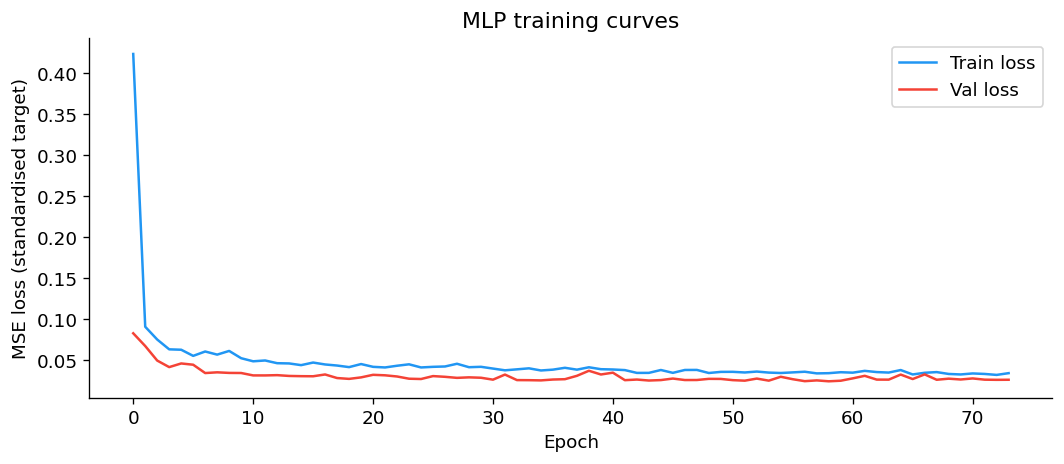

In [131]:
# ── Learning curves ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(train_losses, label="Train loss", color="#2196F3")
ax.plot(val_losses,   label="Val loss",   color="#F44336")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss (standardised target)")
ax.set_title("MLP training curves")
ax.legend()
plt.tight_layout()

fig_path = Path(r"C:\Users\C838122727\Documents\CSU\research\Projects\AI_Bootcamp_Week3\outputs\figures")
fig_path.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path / "learning_curves.png", bbox_inches="tight", dpi=150)
plt.show()


In [132]:
# ── MLP test evaluation ───────────────────────────────────────────────────────
model.eval()
with torch.no_grad():
    X_test_t = torch.tensor(X_test_s, dtype=torch.float32).to(device)
    y_mlp_s  = model(X_test_t).cpu().numpy().ravel()

# Inverse-transform back to W/m²
y_mlp_test = scaler_y.inverse_transform(y_mlp_s.reshape(-1, 1)).ravel()
y_mlp_test = np.where(df["clearsky_ghi"].values[n_train+n_val:] <= 0, 0, np.clip(y_mlp_test, 0, None))

results.append(evaluate(y_test, y_mlp_test, name="MLP"))

print("MLP — Test set:")
print(f"  MAE   = {results[-1]['MAE']:.1f} W/m²")
print(f"  RMSE  = {results[-1]['RMSE']:.1f} W/m²")
print(f"  nRMSE = {results[-1]['nRMSE (%)']:.1f} %")




MLP — Test set:
  MAE   = 34.0 W/m²
  RMSE  = 63.7 W/m²
  nRMSE = 24.2 %


## 7. Model comparison

We compare all three models on the held-out test set.

**Skill score** measures improvement relative to the persistence baseline:

$$\text{Skill} = 1 - \frac{\text{RMSE}_{\text{model}}}{\text{RMSE}_{\text{persistence}}}$$

A skill score of 0 means the model is no better than persistence.  
A skill score of 1 would be perfect. Negative means worse than persistence.


In [133]:
results_df = pd.DataFrame(results)

# Add skill score relative to persistence
rmse_pers = results_df.loc[results_df["Model"] == "Persistence", "RMSE"].values[0]
results_df["Skill score"] = (1 - results_df["RMSE"] / rmse_pers).round(3)
results_df = results_df.set_index("Model")
results_df[["MAE", "RMSE", "nRMSE (%)", "Skill score"]].round(2)


,MAE,RMSE,nRMSE (%),Skill score
Model,,,,
Persistence,79.68,157.12,59.70,0.00
Random Forest,37.87,70.57,26.81,0.55
MLP,33.97,63.74,24.22,0.59


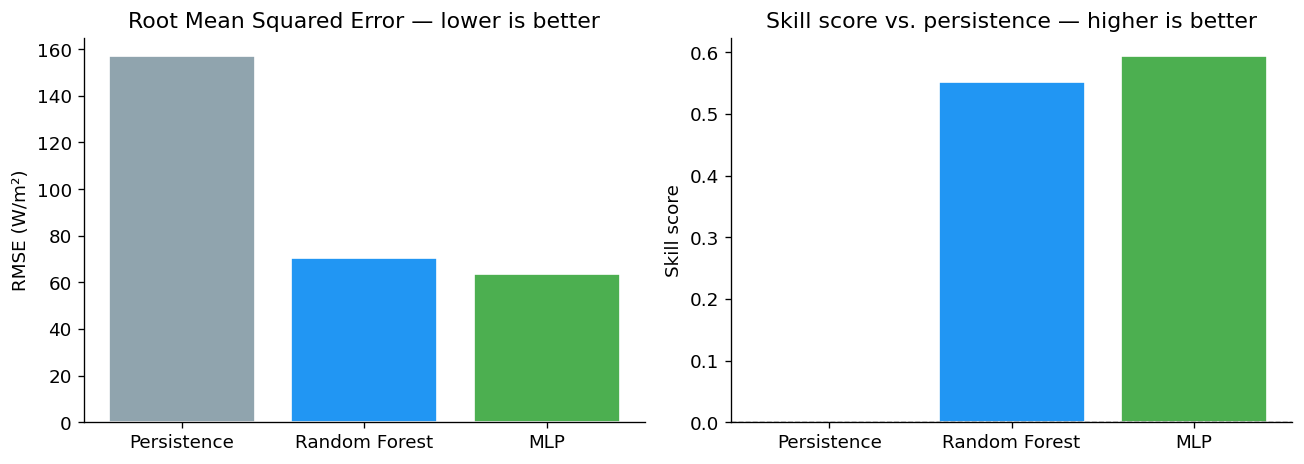

In [134]:
# ── Bar chart comparison ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
colors = ["#90A4AE", "#2196F3", "#4CAF50"]

axes[0].bar(results_df.index, results_df["RMSE"], color=colors, edgecolor="white")
axes[0].set_ylabel("RMSE (W/m²)")
axes[0].set_title("Root Mean Squared Error — lower is better")

axes[1].bar(results_df.index, results_df["Skill score"], color=colors, edgecolor="white")
axes[1].axhline(0, color="black", lw=0.8, ls="--")
axes[1].set_ylabel("Skill score")
axes[1].set_title("Skill score vs. persistence — higher is better")

plt.tight_layout()

fig_path = Path(r"C:\Users\C838122727\Documents\CSU\research\Projects\AI_Bootcamp_Week3\outputs\figures")
fig_path.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path / "models_comparison_barChart.png", bbox_inches="tight", dpi=150)
plt.show()


## 8. Visual inspection — 3-day forecast window

Metrics alone do not tell the full story. Always look at the actual vs. predicted  
time series to understand *where* and *why* the model fails.


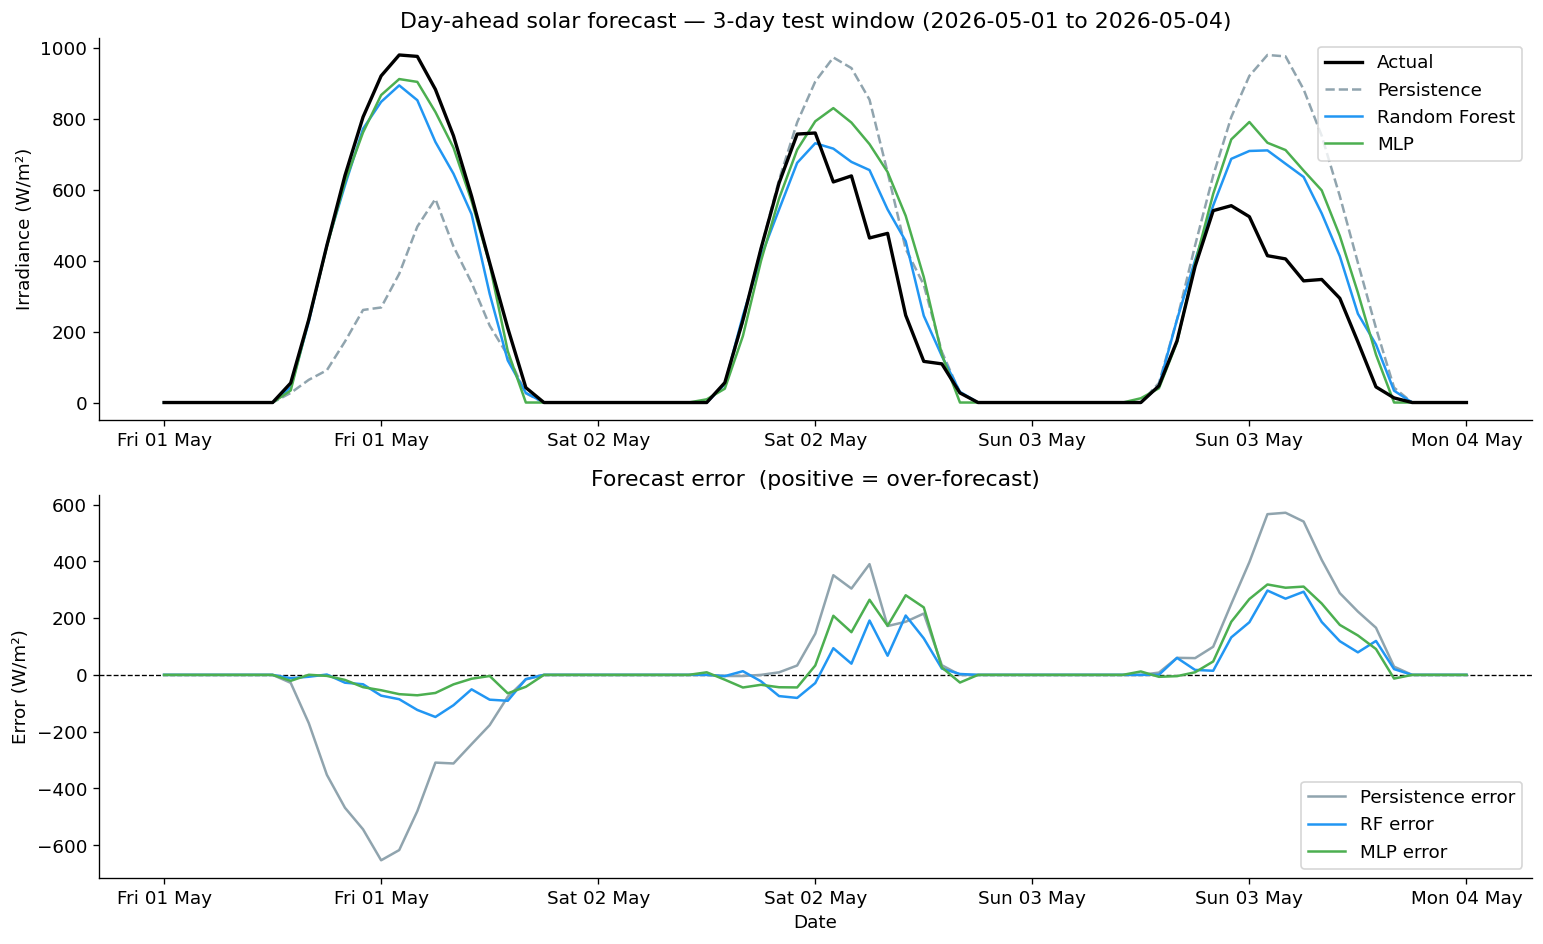

In [135]:
# Find a high-variability window in test set
y_test_series = pd.Series(y_test, index=idx_test)
daily_std = y_test_series.resample("D").std()
most_variable_day = daily_std.nlargest(5).index[2]
plot_start = most_variable_day
plot_end   = plot_start + pd.Timedelta(days=3)

mask  = (idx_test >= plot_start) & (idx_test <= plot_end)
t_win = idx_test[mask]

y_true_win = y_test[mask]
y_pers_win = y_pers[mask]
y_rf_win   = y_rf_test[mask]
y_mlp_win  = y_mlp_test[mask]

fig, axes = plt.subplots(2, 1, figsize=(13, 8))

# ── Top: actual vs. predicted ─────────────────────────────────────────────────
ax = axes[0]
ax.plot(t_win, y_true_win, color="black",    lw=2,   label="Actual",      zorder=5)
ax.plot(t_win, y_pers_win, color="#90A4AE",  lw=1.5, label="Persistence", ls="--")
ax.plot(t_win, y_rf_win,   color="#2196F3",  lw=1.5, label="Random Forest")
ax.plot(t_win, y_mlp_win,  color="#4CAF50",  lw=1.5, label="MLP")
ax.set_ylabel("Irradiance (W/m²)")
ax.set_title(f"Day-ahead solar forecast — 3-day test window "
             f"({plot_start.date()} to {plot_end.date()})")
ax.legend(loc="upper right")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%a %d %b"))

# ── Bottom: error (predicted − actual) ───────────────────────────────────────
ax = axes[1]
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.plot(t_win, y_pers_win - y_true_win, color="#90A4AE", lw=1.5, label="Persistence error")
ax.plot(t_win, y_rf_win   - y_true_win, color="#2196F3", lw=1.5, label="RF error")
ax.plot(t_win, y_mlp_win  - y_true_win, color="#4CAF50", lw=1.5, label="MLP error")
ax.set_ylabel("Error (W/m²)")
ax.set_xlabel("Date")
ax.set_title("Forecast error  (positive = over-forecast)")
ax.legend(loc="lower right")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%a %d %b"))

plt.tight_layout()
fig_path = Path(r"C:\Users\C838122727\Documents\CSU\research\Projects\AI_Bootcamp_Week3\outputs\figures")
fig_path.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path / "forecast_3day.png", bbox_inches="tight", dpi=150)
plt.show()


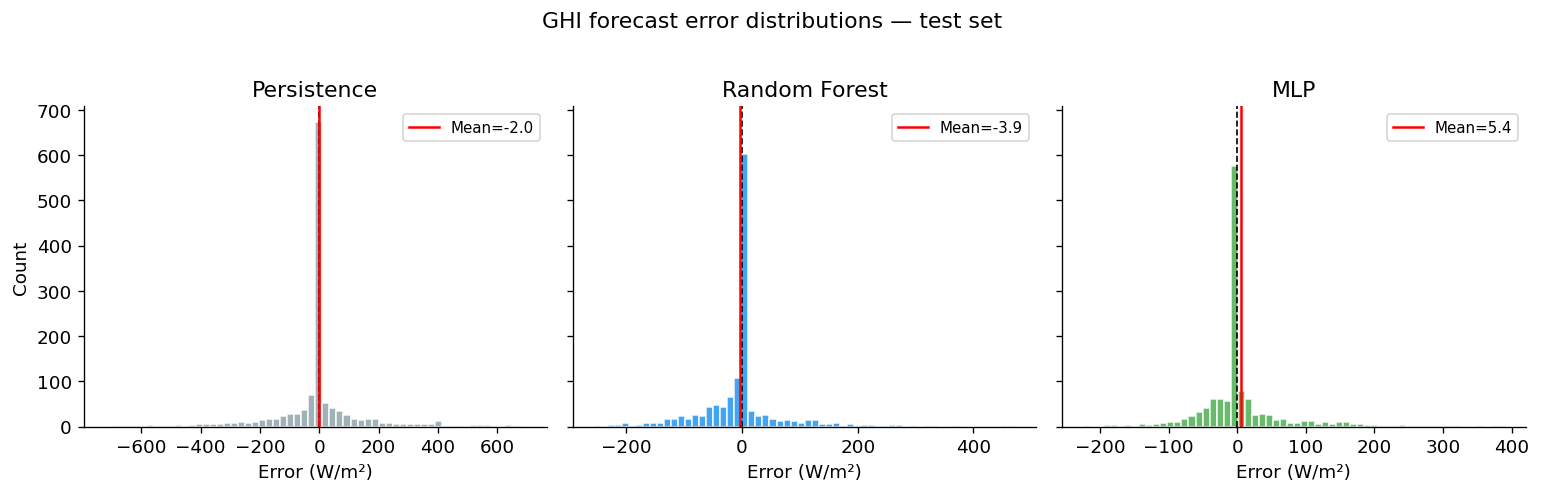

In [136]:
# ── Error distribution ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)

errors = {
    "Persistence" : (y_pers - y_test,  "#90A4AE"),
    "Random Forest": (y_rf_test - y_test, "#2196F3"),
    "MLP"         : (y_mlp_test - y_test, "#4CAF50"),
}

for ax, (name, (err, color)) in zip(axes, errors.items()):
    ax.hist(err, bins=60, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(0,          color="black", lw=1, ls="--")
    ax.axvline(err.mean(), color="red",   lw=1.5, label=f"Mean={err.mean():.1f}")
    ax.set_title(name)
    ax.set_xlabel("Error (W/m²)")
    ax.legend(fontsize=9)

axes[0].set_ylabel("Count")
plt.suptitle("GHI forecast error distributions — test set", y=1.02)
plt.tight_layout()
fig_path = Path(r"C:\Users\C838122727\Documents\CSU\research\Projects\AI_Bootcamp_Week3\outputs\figures")
fig_path.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path / "GHI_error.png", bbox_inches="tight", dpi=150)
plt.show()


---

## Extension: From Irradiance Forecast to PV Power Output

So far we have forecast **solar irradiance** (W/m²). In practice, grid operators
and DER aggregators care about **AC power output** (kW) — what the inverter
actually delivers to the grid.

Converting GHI to AC power requires a physics chain:

$$GHI \xrightarrow{\text{geometry}} POA \xrightarrow{\text{temperature}} P_{DC} \xrightarrow{\text{inverter}} P_{AC}$$

We follow the methodology from Sandia National Laboratory. The full chain
implements equations for:

1. Extraterrestrial irradiance $E_0$
2. Solar zenith angle $Z$ from declination, latitude, hour angle
3. Clearness index $K_t$
4. Diffuse fraction $d_f$ (piecewise, Eq. 5)
5. DHI and DNI decomposition
6. Plane-of-array (POA) irradiance for a tilted south-facing panel
7. Cell temperature from ambient + irradiance heating
8. DC power with temperature correction
9. AC power via inverter efficiency

**System parameters** match a representative 100 kW installation
(panel tilt 30°, south-facing, inverter efficiency 94.5%) adapted for
Powerhouse Energy Campus, CSU, Fort Collins, CO (40.59°N).

In [137]:
# ── Apply physics conversion to already-computed GHI predictions ──────────────
cs_test = df["clearsky_ghi"].values[n_train+n_val:]
t_test  = df["temp_forecast"].shift(24).values[n_train+n_val:]

pv_pers_test   = ghi_to_ac_power(y_pers,     t_test, cs_test) / 1000
pv_rf_test     = ghi_to_ac_power(y_rf_test,  t_test, cs_test) / 1000
pv_mlp_test    = ghi_to_ac_power(y_mlp_test, t_test, cs_test) / 1000
pv_actual_test = ghi_to_ac_power(y_test,     t_test, cs_test) / 1000

# ── Evaluate ──────────────────────────────────────────────────────────────────
pv_results = pd.DataFrame([
    evaluate(pv_actual_test, pv_pers_test,  name="Persistence"),
    evaluate(pv_actual_test, pv_rf_test,    name="Random Forest"),
    evaluate(pv_actual_test, pv_mlp_test,   name="MLP"),
])
rmse_p = pv_results.loc[pv_results["Model"]=="Persistence","RMSE"].values[0]
pv_results["Skill score"] = (1 - pv_results["RMSE"] / rmse_p).round(3)
pv_results = pv_results.set_index("Model")

print("PV AC Power Forecast — Test set (derived from GHI predictions):")
print(pv_results[["MAE","RMSE","nRMSE (%)","Skill score"]].round(2))
print(f"\nPeak system: {P_RATED/1000:.0f} kW rated, "
      f"{P_RATED*ETA_INV/1000:.1f} kW inverter-limited")

PV AC Power Forecast — Test set (derived from GHI predictions):
               MAE   RMSE  nRMSE (%)  Skill score
Model                                            
Persistence    7.1  14.06      62.24         0.00
Random Forest  3.4   6.39      28.29         0.55
MLP            3.0   5.73      25.38         0.59

Peak system: 100 kW rated, 94.5 kW inverter-limited


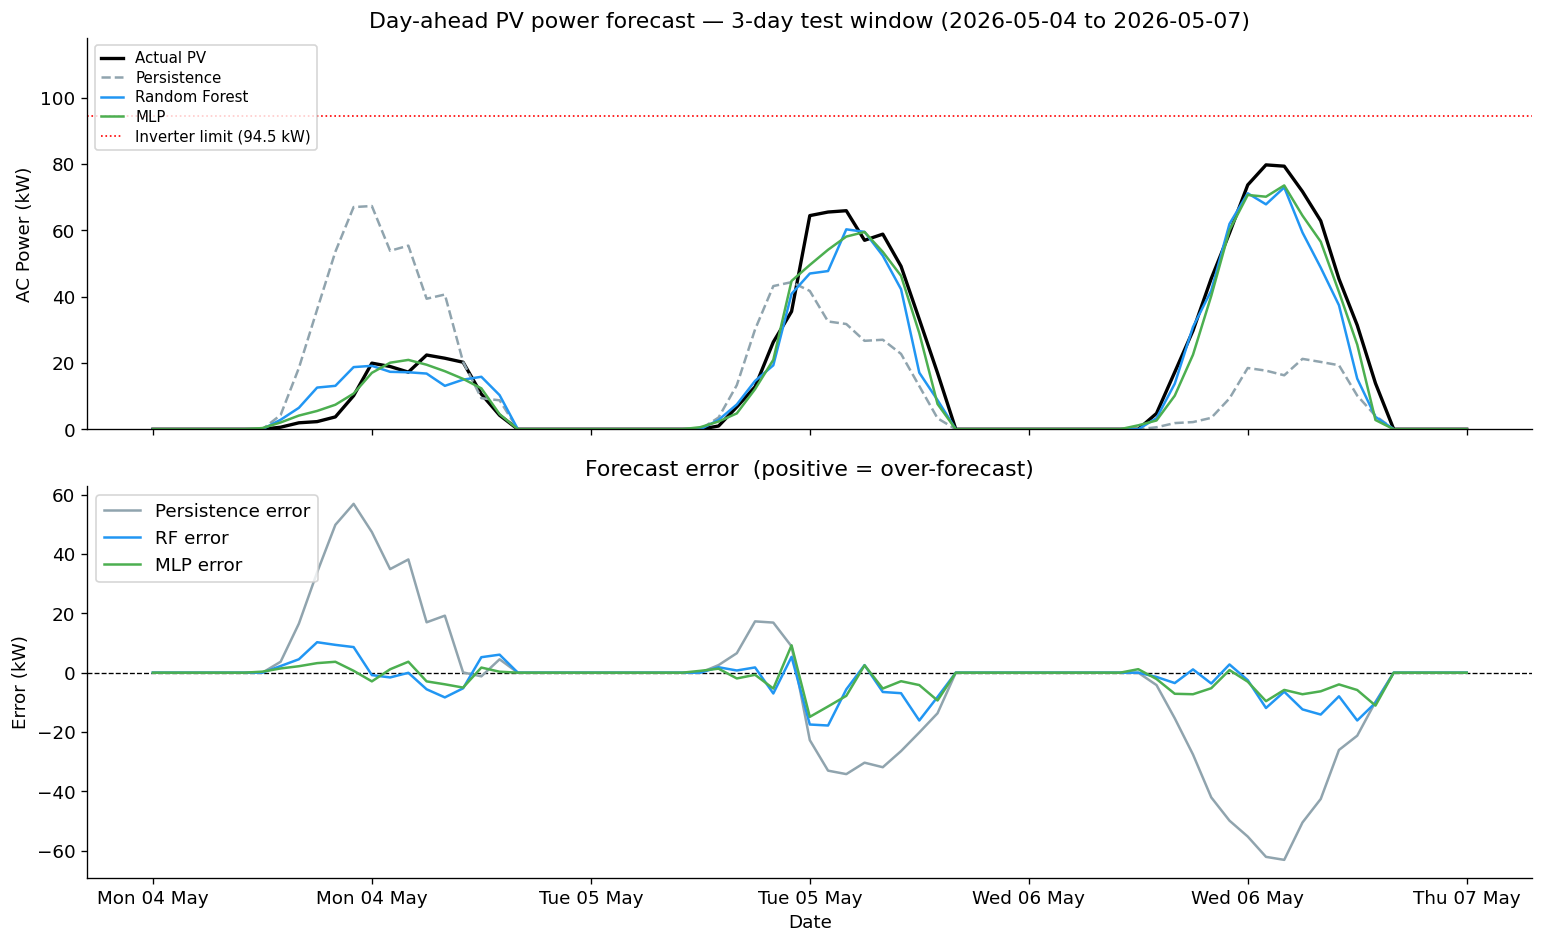

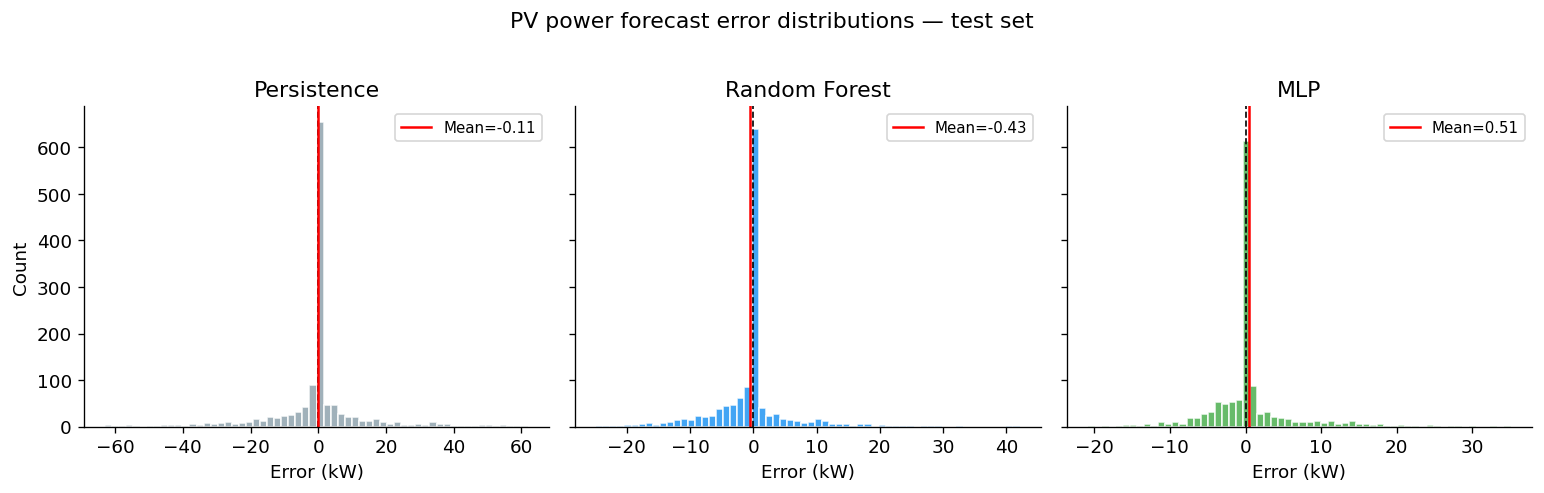

In [147]:
# ── 3-day forecast window — PV AC power ──────────────────────────────────────

# ── Choose any start date from the test set ───────────────────────────────────
# Options from test set: 2026-04-07 to 2026-05-31
# Change this date to explore different weather conditions
PLOT_DATE = "2026-05-04"

plot_start = pd.Timestamp(PLOT_DATE, tz="America/Denver")
plot_end   = plot_start + pd.Timedelta(days=3)

mask  = (idx_test >= plot_start) & (idx_test <= plot_end)
t_win = idx_test[mask]

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

ax = axes[0]
ax.plot(t_win, pv_actual_test[mask],  color="black",   lw=2,   label="Actual PV")
ax.plot(t_win, pv_pers_test[mask],    color="#90A4AE",  lw=1.5, label="Persistence", ls="--")
ax.plot(t_win, pv_rf_test[mask],      color="#2196F3",  lw=1.5, label="Random Forest")
ax.plot(t_win, pv_mlp_test[mask],     color="#4CAF50",  lw=1.5, label="MLP")
ax.axhline(P_RATED * ETA_INV / 1000, color="red", lw=1,
           ls=":", label=f"Inverter limit ({P_RATED*ETA_INV/1000:.1f} kW)")
ax.set_ylabel("AC Power (kW)")
ax.set_title(f"Day-ahead PV power forecast — 3-day test window "
             f"({plot_start.date()} to {plot_end.date()})")
ax.legend(loc="upper left", fontsize=9, markerscale=0.9,
          handlelength=1.5, borderpad=0.4, labelspacing=0.3)
ax.set_ylim(0, P_RATED * ETA_INV / 1000 * 1.25)

ax = axes[1]
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.plot(t_win, pv_pers_test[mask] - pv_actual_test[mask],
        color="#90A4AE", lw=1.5, label="Persistence error")
ax.plot(t_win, pv_rf_test[mask]   - pv_actual_test[mask],
        color="#2196F3", lw=1.5, label="RF error")
ax.plot(t_win, pv_mlp_test[mask]  - pv_actual_test[mask],
        color="#4CAF50", lw=1.5, label="MLP error")
ax.set_ylabel("Error (kW)")
ax.set_xlabel("Date")
ax.set_title("Forecast error  (positive = over-forecast)")
ax.legend(loc="upper left")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%a %d %b"))

plt.tight_layout()
fig_path = Path(r"C:\Users\C838122727\Documents\CSU\research\Projects\AI_Bootcamp_Week3\outputs\figures")
fig_path.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path / "pv_forecast_3day.png", bbox_inches="tight", dpi=150)
plt.show()

# ── Error distribution ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)

pv_errors = {
    "Persistence" : (pv_pers_test - pv_actual_test, "#90A4AE"),
    "Random Forest": (pv_rf_test   - pv_actual_test, "#2196F3"),
    "MLP"         : (pv_mlp_test  - pv_actual_test, "#4CAF50"),
}

for ax, (name, (err, color)) in zip(axes, pv_errors.items()):
    ax.hist(err, bins=60, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(0,          color="black", lw=1,   ls="--")
    ax.axvline(err.mean(), color="red",   lw=1.5, label=f"Mean={err.mean():.2f}")
    ax.set_title(name)
    ax.set_xlabel("Error (kW)")
    ax.legend(fontsize=9)

axes[0].set_ylabel("Count")
plt.suptitle("PV power forecast error distributions — test set", y=1.02)
plt.tight_layout()
fig_path = Path(r"C:\Users\C838122727\Documents\CSU\research\Projects\AI_Bootcamp_Week3\outputs\figures")
fig_path.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path / "pv_forecast_error.png", bbox_inches="tight", dpi=150)
plt.show()

In [118]:
# ── Save forecast outputs to CSV ──────────────────────────────────────────────
forecast_df = pd.DataFrame({
    "actual_ghi"       : y_test,
    "pers_ghi"         : y_pers,
    "rf_ghi"           : y_rf_test,
    "mlp_ghi"          : y_mlp_test,
    "actual_pv_kw"     : pv_actual_test,
    "pers_pv_kw"       : pv_pers_test,
    "rf_pv_kw"         : pv_rf_test,
    "mlp_pv_kw"        : pv_mlp_test,
}, index=idx_test)

forecast_df.index.name = "timestamp"

out_path = r"C:\Users\C838122727\Documents\CSU\research\Projects\AI_Bootcamp_Week3\data\workshop/solar_forecasting_predictions.csv"
forecast_df.to_csv(out_path)

print(f"Saved → {out_path}")
print(f"Shape : {forecast_df.shape}")
print(f"\nSample:")
print(forecast_df.head(3).round(2))

Saved → C:\Users\C838122727\Documents\CSU\research\Projects\AI_Bootcamp_Week3\data\workshop/solar_forecasting_predictions.csv
Shape : (1308, 8)

Sample:
                           actual_ghi  pers_ghi  rf_ghi     mlp_ghi  \
timestamp                                                             
2026-04-07 06:00:00-06:00         0.0       0.0    0.00    0.000000   
2026-04-07 07:00:00-06:00         7.0       5.0    5.68   18.309999   
2026-04-07 08:00:00-06:00       130.0     114.0  116.95  110.059998   

                           actual_pv_kw  pers_pv_kw  rf_pv_kw  mlp_pv_kw  
timestamp                                                                 
2026-04-07 06:00:00-06:00          0.00        0.00      0.00       0.00  
2026-04-07 07:00:00-06:00          0.52        0.37      0.42       1.36  
2026-04-07 08:00:00-06:00          9.77        8.55      8.78       8.25  


## 9. Discussion — what good solar forecasting means for power systems

A low RMSE is not enough. In power systems, forecast errors have asymmetric costs:

| Error type | Consequence |
|---|---|
| Over-forecast (predict too much solar) | Grid operator schedules too little backup generation → potential under-supply |
| Under-forecast (predict too little solar) | Grid operator schedules unnecessary reserve → wasted cost |

**Other considerations:**
- **Ramp events** — sudden drops in irradiance from cloud passage are the hardest to forecast and the most damaging to grid stability
- **Extreme errors** — a single large error at peak demand is more costly than many small errors overnight
- **Calibration** — a useful forecast should also provide uncertainty bounds (prediction intervals), not just point estimates

**Where to go next:**
1. Add a **gradient boosting** model (XGBoost/LightGBM) — typically the strongest tabular benchmark
2. Replace the MLP with a **temporal convolutional network** or **LSTM** to explicitly model the time sequence
3. Wrap predictions with **conformal prediction** to get calibrated uncertainty intervals
4. Apply this pipeline to **load forecasting** (very similar structure, different target)

> *"A 1% improvement in day-ahead solar forecast accuracy can reduce balancing costs
> by tens of millions of dollars annually at the ISO scale."*
> — Typical finding in power systems operations literature


## 10. Save the trained MLP (optional)

In [119]:
import os
from pathlib import Path

save_dir = Path(r"C:\Users\C838122727\Documents\CSU\research\Projects\AI_Bootcamp_Week3\models\instructor")
save_dir.mkdir(parents=True, exist_ok=True)

torch.save({
    "model_state_dict"  : model.state_dict(),
    "scaler_X_mean"     : scaler_X.mean_,
    "scaler_X_scale"    : scaler_X.scale_,
    "scaler_y_mean"     : scaler_y.mean_,
    "scaler_y_scale"    : scaler_y.scale_,
    "feature_cols"      : FEATURE_COLS,
    "test_rmse"         : float(results_df.loc["MLP", "RMSE"]),
    "metadata": {
        "location"  : "Fort Collins CO",
        "period"    : "Jun 2025 - May 2026",
        "seed"      : SEED,
    }
}, save_dir / "forecasting_mlp.pt")

print(f"Model saved to {save_dir / 'forecasting_mlp.pt'}")


Model saved to C:\Users\C838122727\Documents\CSU\research\Projects\AI_Bootcamp_Week3\models\instructor\forecasting_mlp.pt
